# scatter
> Dimensionality-reduction, scatter, and correlation.

In [ ]:
#| default_exp scatter

In [ ]:
#| export
from pathlib import Path

import joblib
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from fastcore.meta import delegates
from matplotlib import pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap.umap_ import UMAP

/Users/icai/Documents/git/kplot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = sns.load_dataset('penguins').dropna().reset_index(drop=True)
df2 = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
print(df.shape)
print(df2.shape)

(333, 7)
(333, 4)


In [ ]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Dimensionality Reduction

In [ ]:
#| export
def reduce_feature(
    df: pd.DataFrame,  # numeric feature matrix
    method: str = 'pca',  # one of pca, tsne, umap
    complexity: int = 20,  # perplexity for tsne or neighbors for umap
    n: int = 2,  # number of output dimensions
    load: str | Path | None = None,  # path to a previously fitted reducer
    save: str | Path | None = None,  # optional path for persisting the reducer
    seed: int = 123,  # random_state used by reducers that support it
    **kwargs,  # forwarded reducer kwargs
) -> pd.DataFrame:
    "Reduce a feature matrix to a lower-dimensional embedding dataframe."
    method = method.lower()
    if method not in {'pca', 'tsne', 'umap'}:
        raise ValueError('Please choose a method among PCA, TSNE, and UMAP')

    if load is not None:
        reducer = joblib.load(load)
        if hasattr(reducer, 'transform'):
            projection = reducer.transform(df)
        else:
            projection = reducer.fit_transform(df)
    else:
        if method == 'pca':
            reducer = PCA(n_components=n, random_state=seed, **kwargs)
        elif method == 'tsne':
            reducer = TSNE(n_components=n, random_state=seed, perplexity=complexity, **kwargs)
        else:
            reducer = UMAP(n_components=n, random_state=seed, n_neighbors=complexity, **kwargs)
        projection = reducer.fit_transform(df)

        if save is not None:
            save_path = Path(save)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            joblib.dump(reducer, save_path)

    embedding_df = pd.DataFrame(projection, index=df.index)
    embedding_df.columns = [f'{method.upper()}{i}' for i in range(1, embedding_df.shape[1] + 1)]
    return embedding_df

In [ ]:
reduce_feature(df2, method='pca', n=2)

,PCA1,PCA2
0,-457.325073,-13.351587
1,-407.252205,-9.179113
2,-957.044676,8.160444
3,-757.115802,1.867653
4,-557.177302,-3.389158
...,...,...
328,718.068699,2.338199
329,643.090909,4.280699
330,1543.098355,-2.232010
331,992.994900,-4.605154


## Scatter Plots

In [ ]:
#| export
def plot_2d(
    embedding_df: pd.DataFrame,  # dataframe with at least two numeric columns
    hue: str | None = None,  # column name used for color when present in embedding_df
    palette: str = 'tab20',  # seaborn palette name
    legend: bool = False,  # whether to draw a legend
    name_list: list[str] | None = None,  # labels used to annotate points
    s: int = 20,  # marker size
    legend_title: str | None = None,  # optional legend title override
    **kwargs,  # forwarded scatterplot kwargs
):
    "Plot the first two columns of an embedding dataframe."
    if embedding_df.shape[1] < 2:
        raise ValueError('embedding_df must contain at least two columns to plot in 2D')
    if hue is not None and hue not in embedding_df.columns:
        raise ValueError(f'hue column {hue!r} not found in embedding_df')
    if name_list is not None and len(name_list) != len(embedding_df):
        raise ValueError('name_list must have the same length as embedding_df')

    x_col, y_col = embedding_df.columns[:2]
    fig, ax = plt.subplots(figsize=kwargs.pop('figsize', (6, 4)))
    scatter_kwargs = dict(data=embedding_df, x=x_col, y=y_col, s=s, alpha=0.8, legend=legend, ax=ax, **kwargs)
    if hue is not None:
        scatter_kwargs['hue'] = hue
        scatter_kwargs['palette'] = palette
    sns.scatterplot(**scatter_kwargs)
    ax.set_xticks([])
    ax.set_yticks([])

    if legend and legend_title is not None and ax.legend_ is not None:
        ax.legend_.set_title(legend_title)

    if name_list is not None:
        texts = [
            ax.text(embedding_df[x_col].iloc[i], embedding_df[y_col].iloc[i], str(name_list[i]), fontsize=8)
            for i in range(len(embedding_df))
        ]
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'))
    return ax

<Axes: xlabel='PCA1', ylabel='PCA2'>

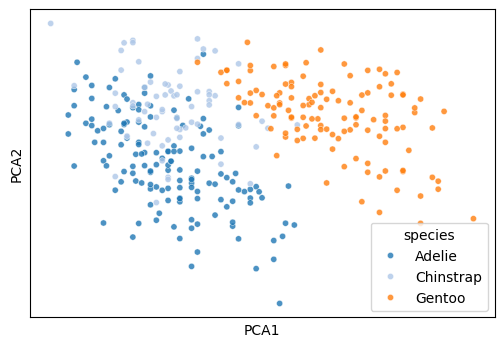

In [ ]:
df2 = reduce_feature(df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']], method='pca', n=2)
df2['species'] = df['species'].values
plot_2d(df2, hue='species', legend=True)

In [ ]:
#| export
def plot_cluster(
    df: pd.DataFrame,  # numeric feature matrix, optionally including a hue column
    method: str = 'pca',  # one of pca, tsne, umap
    hue: str | pd.Series | list | None = None,  # hue column name or per-row hue values
    complexity: int = 30,  # perplexity for tsne or neighbors for umap
    palette: str = 'tab20',  # seaborn palette name
    legend: bool = False,  # whether to draw a legend
    name_list: list[str] | None = None,  # point annotations
    seed: int = 123,  # random seed passed to the reducer
    s: int = 50,  # marker size
    legend_title: str | None = None,  # optional legend title override
    **kwargs,  # forwarded reducer kwargs
):
    "Reduce features and immediately plot the first two embedding dimensions."
    feature_df = df
    hue_arg = None

    if isinstance(hue, str):
        if hue not in df.columns:
            raise ValueError(f'hue column {hue!r} not found in df')
        feature_df = df.drop(columns=[hue])
        hue_values = df[hue].values
        hue_arg = hue
    elif hue is not None:
        hue_values = pd.Series(hue, index=df.index)
        if len(hue_values) != len(df):
            raise ValueError('hue values must have the same length as df')
        hue_values = hue_values.values
        hue_arg = '_hue'
    else:
        hue_values = None

    embedding_df = reduce_feature(feature_df, method=method, seed=seed, complexity=complexity, **kwargs)

    if hue_values is not None:
        embedding_df = embedding_df.copy()
        embedding_df[hue_arg] = hue_values

    return plot_2d(
        embedding_df,
        hue=hue_arg,
        palette=palette,
        legend=legend,
        name_list=name_list,
        s=s,
        legend_title=legend_title,
    )

<Axes: xlabel='PCA1', ylabel='PCA2'>

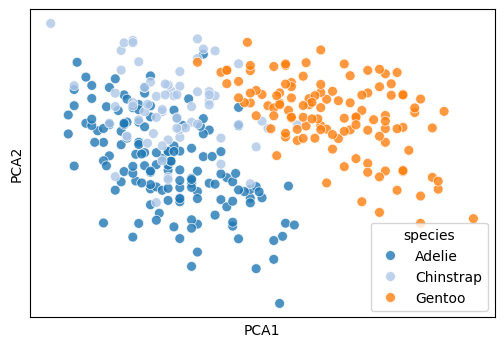

In [ ]:
plot_cluster(df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']], method='pca', hue='species', legend=True)

## Correlation Plot

In [ ]:
#| export
@delegates(sns.regplot)
def plot_rel(
    df: pd.DataFrame,  # dataframe that contains the x and y columns
    x: str,  # x-axis column name
    y: str,  # y-axis column name
    text_location: tuple[float, float] = (0.8, 0.1),  # annotation location in axes coordinates
    method: str | None = 'spearman',  # one of spearman, pearson, or None
    index_list: list[str] | None = None,  # row labels to annotate
    hue: str | None = None,  # optional categorical hue column
    reg_line: bool = True,  # whether to draw a regression line when hue is used
    **kwargs,  # forwarded seaborn kwargs
):
    "Plot a pairwise relationship with an optional correlation annotation."
    fig, ax = plt.subplots(figsize=kwargs.pop('figsize', (6, 4)))
    x_vals = df[x]
    y_vals = df[y]

    if hue is not None:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, ax=ax, **kwargs)
        if reg_line:
            sns.regplot(x=x_vals, y=y_vals, scatter=False, line_kws={'color': 'gray', 'alpha': 0.5}, ax=ax)
        if ax.legend_ is not None:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.0)
    else:
        sns.regplot(x=x_vals, y=y_vals, line_kws={'color': 'gray'}, ax=ax, **kwargs)

    if method is not None:
        if method.lower() == 'spearman':
            corr_val, pvalue = spearmanr(x_vals, y_vals)
            corr_label = f'Spearman ρ = {corr_val:.2f}\n p = {pvalue:.2e}'
        elif method.lower() == 'pearson':
            corr_val, pvalue = pearsonr(x_vals, y_vals)
            corr_label = f'Pearson r = {corr_val:.2f}\n p = {pvalue:.2e}'
        else:
            raise ValueError('method must be one of spearman, pearson, or None')
        ax.text(text_location[0], text_location[1], corr_label, transform=ax.transAxes, ha='center', va='center')

    texts = []
    if index_list is not None:
        for idx in index_list:
            if idx in df.index:
                texts.append(ax.text(x_vals.loc[idx], y_vals.loc[idx], str(idx), fontsize=9, ha='center', va='center'))
        if texts:
            adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5), ax=ax)
    return ax

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

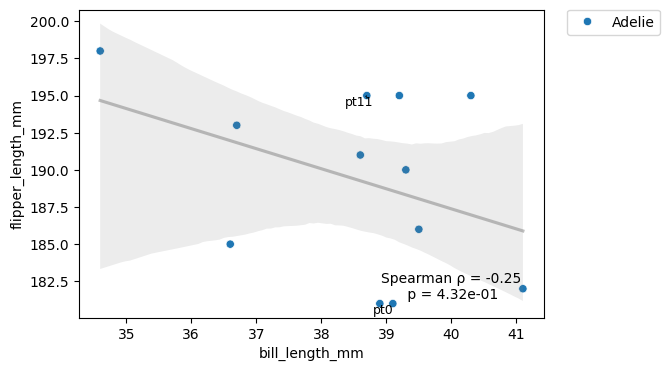

In [ ]:
df2 = df[['bill_length_mm', 'flipper_length_mm', 'species']].head(12).copy()
df2.index = [f'pt{i}' for i in range(len(df2))]
plot_rel(df2, x='bill_length_mm', y='flipper_length_mm', hue='species', index_list=['pt0', 'pt11'])

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()